In [76]:
import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt



In [77]:
df = pd.read_csv(r"C:\Users\ananya\Downloads\customer churn\customer_support_tickets.csv")  # adjust filename if needed
df.head()


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [78]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [79]:
df.columns


Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [80]:
df['combined_text'] = df['Ticket Subject'] + " " + df['Ticket Description']

df[['Ticket Subject', 'Ticket Description', 'combined_text']].head()


,Ticket Subject,Ticket Description,combined_text
0,Product setup,I'm having an issue with the {product_purchase...,Product setup I'm having an issue with the {pr...
1,Peripheral compatibility,I'm having an issue with the {product_purchase...,Peripheral compatibility I'm having an issue w...
2,Network problem,I'm facing a problem with my {product_purchase...,Network problem I'm facing a problem with my {...
3,Account access,I'm having an issue with the {product_purchase...,Account access I'm having an issue with the {p...
4,Data loss,I'm having an issue with the {product_purchase...,Data loss I'm having an issue with the {produc...


In [81]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)
    return score['compound']

df['sentiment_score'] = df['combined_text'].apply(get_sentiment)

df[['combined_text', 'sentiment_score']].head()


,combined_text,sentiment_score
0,Product setup I'm having an issue with the {pr...,0.5423
1,Peripheral compatibility I'm having an issue w...,0.4019
2,Network problem I'm facing a problem with my {...,0.1655
3,Account access I'm having an issue with the {p...,0.6956
4,Data loss I'm having an issue with the {produc...,-0.3318


In [82]:
df['sentiment_score'].describe()


count    8469.000000
mean        0.227730
std         0.437657
min        -0.954900
25%        -0.099400
50%         0.282400
75%         0.562500
max         0.984400
Name: sentiment_score, dtype: float64

In [83]:
df['churn_risk'] = 0

df.loc[
    (df['Customer Satisfaction Rating'] <= 2) |
    (
        (df['sentiment_score'] < -0.2) &
        (df['Ticket Priority'].isin(['High', 'Critical']))
    ),
    'churn_risk'
] = 1

df['churn_risk'].value_counts()



churn_risk
0    6653
1    1816
Name: count, dtype: int64

In [84]:
le_priority = LabelEncoder()
le_channel = LabelEncoder()

df['priority_encoded'] = le_priority.fit_transform(df['Ticket Priority'])
df['channel_encoded'] = le_channel.fit_transform(df['Ticket Channel'])


In [85]:
X_structured = df[['Customer Age',
                   'priority_encoded',
                   'channel_encoded',
                   'sentiment_score']]


In [93]:
df['Customer Satisfaction Rating'] = df['Customer Satisfaction Rating'].fillna(3)   #NaN


In [94]:
df[['Customer Age',
    'Customer Satisfaction Rating',
    'priority_encoded',
    'channel_encoded',
    'sentiment_score']].isna().sum()


Customer Age                    0
Customer Satisfaction Rating    0
priority_encoded                0
channel_encoded                 0
sentiment_score                 0
dtype: int64

In [95]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# Text vectorization
vectorizer = TfidfVectorizer(max_features=1000)
X_text = vectorizer.fit_transform(df['combined_text'])

# Structured features
X_structured = df[[
    'Customer Age',
    'Customer Satisfaction Rating',
    'priority_encoded',
    'channel_encoded',
    'sentiment_score'
]]

# Combine text + structured
X_final = hstack([X_text, X_structured])

# Target
y = df['churn_risk']

print("Final feature shape:", X_final.shape)


Final feature shape: (8469, 1005)


In [96]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [97]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [98]:
y_proba = model.predict_proba(X_test)[:, 1]

# Lower threshold from 0.5 to 0.4
y_pred_adjusted = (y_proba >= 0.4).astype(int)


In [100]:
from sklearn.metrics import classification_report, accuracy_score

# Lower threshold predictions
y_proba = model.predict_proba(X_test)[:, 1]
y_pred_adjusted = (y_proba >= 0.4).astype(int)

# Evaluate
print("Accuracy (adjusted threshold):", accuracy_score(y_test, y_pred_adjusted))
print("\nClassification Report (adjusted threshold):\n")
print(classification_report(y_test, y_pred_adjusted))


Accuracy (adjusted threshold): 0.9828807556080283

Classification Report (adjusted threshold):

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1331
           1       0.98      0.94      0.96       363

    accuracy                           0.98      1694
   macro avg       0.98      0.97      0.97      1694
weighted avg       0.98      0.98      0.98      1694



<Figure size 600x600 with 0 Axes>

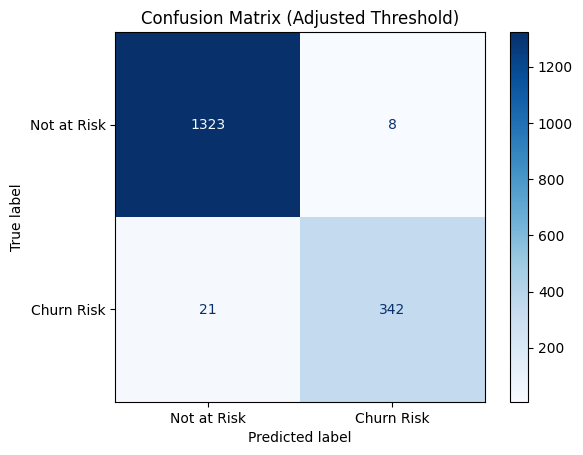

In [101]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrix for adjusted threshold
cm = confusion_matrix(y_test, y_pred_adjusted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not at Risk', 'Churn Risk'])

plt.figure(figsize=(6,6))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Adjusted Threshold)")
plt.show()


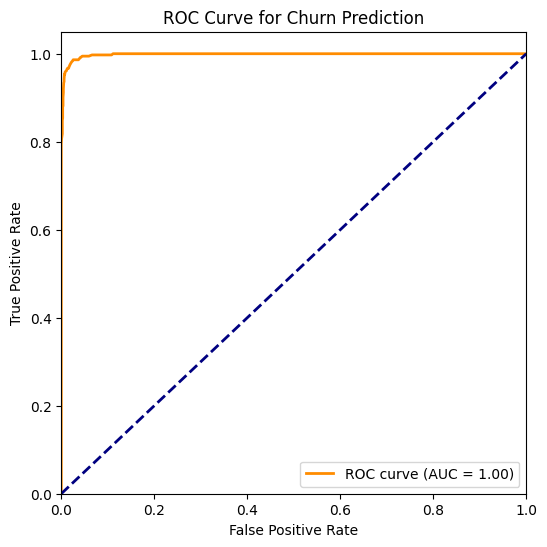

In [102]:
from sklearn.metrics import roc_curve, auc

# Probabilities for class 1
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Churn Prediction')
plt.legend(loc="lower right")
plt.show()


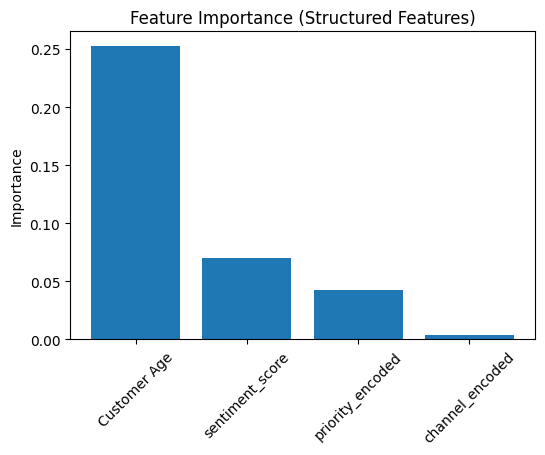

In [103]:
import numpy as np

# Only structured features importance
feature_names = ['Customer Age', 'priority_encoded', 'channel_encoded', 'sentiment_score']
importances = model.feature_importances_[-4:]  # last 4 are structured

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(6,4))
plt.title("Feature Importance (Structured Features)")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45)
plt.ylabel("Importance")
plt.show()


Top 20 TF-IDF words driving churn:

                  word  importance
636             please    0.015347
652            problem    0.010721
407             having    0.009924
461              issue    0.009839
107             assist    0.009178
867                the    0.009117
663  product_purchased    0.008864
83                  an    0.008762
981               with    0.008366
887                 to    0.008288
551                 my    0.007035
463                 it    0.006251
941                 ve    0.005862
459                 is    0.005650
84                 and    0.005598
145                but    0.005074
998                you    0.005021
878               this    0.004954
848            support    0.004822
585                 on    0.004809


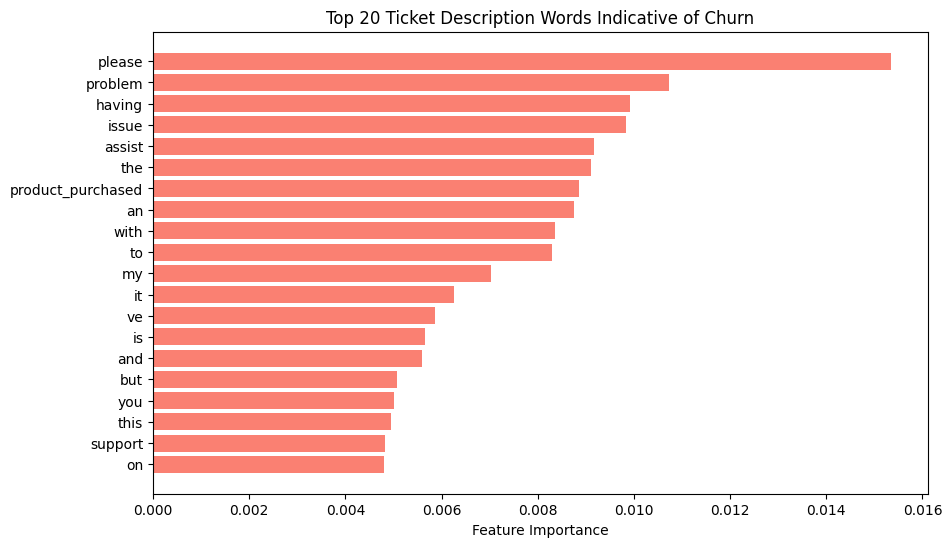

In [105]:
import pandas as pd
import numpy as np

# Get feature names from TF-IDF
tfidf_feature_names = vectorizer.get_feature_names_out()

# Random Forest feature importances
all_importances = model.feature_importances_

# Structured features are the last 4, so text features are the first
text_importances = all_importances[:len(tfidf_feature_names)]

# Create a DataFrame
tfidf_importance_df = pd.DataFrame({
    'word': tfidf_feature_names,
    'importance': text_importances
})

# Sort by importance descending
tfidf_importance_df = tfidf_importance_df.sort_values(by='importance', ascending=False)

# Show top 20 words indicative of churn
top_words = tfidf_importance_df.head(20)
print("Top 20 TF-IDF words driving churn:\n")
print(top_words)

# Optional: bar plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(top_words['word'][::-1], top_words['importance'][::-1], color='salmon')
plt.xlabel("Feature Importance")
plt.title("Top 20 Ticket Description Words Indicative of Churn")
plt.show()


In [106]:
# Get the top TF-IDF words as a list
top_tfidf_words = top_words['word'].tolist()

# Function to get top words present in a ticket
def get_top_words_in_ticket(text, top_words_list):
    text_words = text.lower().split()
    matched = [word for word in top_words_list if word in text_words]
    return matched if matched else ["None"]

# Create explanation column
df['churn_reason'] = df.apply(
    lambda row: {
        "Low Satisfaction": row['Customer Satisfaction Rating'] <= 2,
        "High Priority Ticket": row['Ticket Priority'] in ['High', 'Critical'],
        "Negative Sentiment": row['sentiment_score'] < -0.2,
        "Top Complaint Words": get_top_words_in_ticket(row['combined_text'], top_tfidf_words)
    },
    axis=1
)

# Show sample flagged customers
churn_customers = df[df['churn_risk'] == 1][['Customer Name', 'churn_risk', 'churn_reason']].head(10)
churn_customers


,Customer Name,churn_risk,churn_reason
4,Alexander Carroll,1,"{'Low Satisfaction': True, 'High Priority Tick..."
10,Joseph Moreno,1,"{'Low Satisfaction': True, 'High Priority Tick..."
11,Brandon Arnold,1,"{'Low Satisfaction': True, 'High Priority Tick..."
29,Austin George,1,"{'Low Satisfaction': True, 'High Priority Tick..."
35,Joann King,1,"{'Low Satisfaction': True, 'High Priority Tick..."
44,Donald Gibbs,1,"{'Low Satisfaction': True, 'High Priority Tick..."
46,Cassandra Richards,1,"{'Low Satisfaction': True, 'High Priority Tick..."
47,Kristen Perry,1,"{'Low Satisfaction': True, 'High Priority Tick..."
60,Amanda Burton,1,"{'Low Satisfaction': True, 'High Priority Tick..."
69,Michael Day,1,"{'Low Satisfaction': True, 'High Priority Tick..."
